In [78]:
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import Runnable
# from langchain_aws import ChatBedrock
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import AnyMessage, add_messages
from langchain_core.messages import ToolMessage
from langchain_core.runnables import RunnableLambda
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

@tool
def compute_savings(monthly_cost: float) -> float:
    """
    Tool to compute the potential savings when switching to solar energy based on the user's monthly electricity cost.
    
    Args:
        monthly_cost (float): The user's current monthly electricity cost.
    
    Returns:
        dict: A dictionary containing:
            - 'number_of_panels': The estimated number of solar panels required.
            - 'installation_cost': The estimated installation cost.
            - 'net_savings_10_years': The net savings over 10 years after installation costs.
    """
    def calculate_solar_savings(monthly_cost):
        # Assumptions for the calculation
        cost_per_kWh = 0.28  
        cost_per_watt = 1.50  
        sunlight_hours_per_day = 3.5  
        panel_wattage = 350  
        system_lifetime_years = 10  

        # Monthly electricity consumption in kWh
        monthly_consumption_kWh = monthly_cost / cost_per_kWh
        
        # Required system size in kW
        daily_energy_production = monthly_consumption_kWh / 30
        system_size_kW = daily_energy_production / sunlight_hours_per_day
        
        # Number of panels and installation cost
        number_of_panels = system_size_kW * 1000 / panel_wattage
        installation_cost = system_size_kW * 1000 * cost_per_watt
        
        # Annual and net savings
        annual_savings = monthly_cost * 12
        total_savings_10_years = annual_savings * system_lifetime_years
        net_savings = total_savings_10_years - installation_cost
        
        return {
            "number_of_panels": round(number_of_panels),
            "installation_cost": round(installation_cost, 2),
            "net_savings_10_years": round(net_savings, 2)
        }

    # Return calculated solar savings
    return calculate_solar_savings(monthly_cost)


def _print_event(event: dict, _printed: set, max_length=1500):
    current_state = event.get("dialog_state")
    if current_state:
        print("Currently in: ", current_state[-1])
    message = event.get("messages")
    if message:
        if isinstance(message, list):
            message = message[-1]
        if message.id not in _printed:
            msg_repr = message.pretty_repr(html=True)
            if len(msg_repr) > max_length:
                msg_repr = msg_repr[:max_length] + " ... (truncated)"
            print(msg_repr)
            _printed.add(message.id)

def handle_tool_error(state) -> dict:
    """
    Function to handle errors that occur during tool execution.
    
    Args:
        state (dict): The current state of the AI agent, which includes messages and tool call details.
    
    Returns:
        dict: A dictionary containing error messages for each tool that encountered an issue.
    """
    # Retrieve the error from the current state
    error = state.get("error")
    
    # Access the tool calls from the last message in the state's message history
    tool_calls = state["messages"][-1].tool_calls
    
    # Return a list of ToolMessages with error details, linked to each tool call ID
    return {
        "messages": [
            ToolMessage(
                content=f"Error: {repr(error)}\n please fix your mistakes.",  # Format the error message for the user
                tool_call_id=tc["id"],  # Associate the error message with the corresponding tool call ID
            )
            for tc in tool_calls  # Iterate over each tool call to produce individual error messages
        ]
    }

def create_tool_node_with_fallback(tools: list) -> dict:
    """
    Function to create a tool node with fallback error handling.
    
    Args:
        tools (list): A list of tools to be included in the node.
    
    Returns:
        dict: A tool node that uses fallback behavior in case of errors.
    """
    # Create a ToolNode with the provided tools and attach a fallback mechanism
    # If an error occurs, it will invoke the handle_tool_error function to manage the error
    return ToolNode(tools).with_fallbacks(
        [RunnableLambda(handle_tool_error)],  # Use a lambda function to wrap the error handler
        exception_key="error"  # Specify that this fallback is for handling errors
    )

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

class Assistant:
    def __init__(self, runnable: Runnable):
        # Initialize with the runnable that defines the process for interacting with the tools
        self.runnable = runnable

    def __call__(self, state: State):
        while True:
            # Invoke the runnable with the current state (messages and context)
            result = self.runnable.invoke(state)
            
            # If the tool fails to return valid output, re-prompt the user to clarify or retry
            if not result.tool_calls and (
                not result.content
                or isinstance(result.content, list)
                and not result.content[0].get("text")
            ):
                # Add a message to request a valid response
                messages = state["messages"] + [("user", "Respond with a real output.")]
                state = {**state, "messages": messages}
            else:
                # Break the loop when valid output is obtained
                break

        # Return the final state after processing the runnable
        return {"messages": result}
    
llm = ChatOpenAI(model="gpt-4.1-nano-2025-04-14")

# llm = create_bedrock_llm(get_bedrock_client(region='us-east-1'))

primary_assistant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            '''You are a helpful customer support assistant for Solar Panels Belgium.
            You should get the following information from them:
            - monthly electricity cost
            If you are not able to discern this info, ask them to clarify! Do not attempt to wildly guess.

            After you are able to discern all the information, call the relevant tool.
            ''',
        ),
        ("placeholder", "{messages}"),
    ]
)

# Define the tools the assistant will use
part_1_tools = [
    compute_savings
]

# Bind the tools to the assistant's workflow
part_1_assistant_runnable = primary_assistant_prompt | llm.bind_tools(part_1_tools)

builder = StateGraph(State)
builder.add_node("assistant", Assistant(part_1_assistant_runnable))
builder.add_node("tools", create_tool_node_with_fallback(part_1_tools))

builder.add_edge(START, "assistant")  # Start with the assistant
builder.add_conditional_edges("assistant", tools_condition)  # Move to tools after input
builder.add_edge("tools", "assistant")  # Return to assistant after tool execution

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)


KeyboardInterrupt: 

In [ ]:
import uuid

thread_id = str(uuid.uuid4())

config = {
    "configurable": {
        "thread_id": thread_id,
    }
}

_printed = set()

while True:
    # Prompt the user for input
    user_input = input("You: ")
    
    # Break the loop if the user wants to exit
    if user_input.lower() in ["exit", "quit","Bye"]:
        print("Exiting the conversation. Goodbye!")
        break

    # Process the user's input through the graph
    events = graph.stream(
        {"messages": ("user", user_input)}, config, stream_mode="values"
    )
    for event in events:
        _print_event(event, _printed)

================================ Human Message =================================

hey
================================== Ai Message ==================================

Hello! Welcome to Solar Panels Belgium. Could you please tell me your current monthly electricity cost? This will help me provide you with better information.
================================ Human Message =================================

around 250 quid
================================== Ai Message ==================================

Thank you for providing your monthly electricity cost as around 250 pounds. I will now proceed to calculate your potential savings with solar panels. Please hold on a moment.
Tool Calls:
  compute_savings (call_b6IPqSwoR91ciwq3eECO82tf)
 Call ID: call_b6IPqSwoR91ciwq3eECO82tf
  Args:
    monthly_cost: 250
================================= Tool Message =================================
Name: compute_savings

{"number_of_panels": 24, "installation_cost": 12755.1, "net_savings_10_years": 172

In [ ]:
def maxContainers( n: int, w: int, maxWeight: int) -> int:

    total_ship_weight = (n*n)*w
    
    if total_ship_weight < maxWeight: 
        return n*n
    elif n ==1: 
        return 1
    else: 
        for i in range(1,n*n):
            temp_weitht = i*w
            if i*w == maxWeight:
                print('if loop')
                return i
            elif i*w > maxWeight:
                print('elif loop')
                return i-1
            else:
                print('else loop')
                pass
            
n = 2 
w = 4 
maxWeight = 16

ans =maxContainers(n, w, maxWeight)

<class 'int'>
<class 'int'>
else loop
<class 'int'>
<class 'int'>
else loop
<class 'int'>
<class 'int'>
else loop


In [ ]:
pdf_path = "example_pdf_for_agent.pdf"  

import pdfplumber

def text_tool(pdf_path: str) -> str:
    all_text = ""
    with pdfplumber.open(pdf_path) as pdf:
        for page_no, page in enumerate(pdf.pages):
            text = page.extract_text()
            if text:
                all_text += "\n" + 'Page Number: ' + f'{(page_no + 1)}' + "\n" + "\n" + text + "\n"
    return all_text

text = text_tool(pdf_path)

In [67]:
import cv2 
from openai import OpenAI
import base64

def encode_image(image_path):
  with open(image_path, "rb") as image_file:
    return base64.b64encode(image_file.read()).decode('utf-8')
  
def openai_responses(open_ai_client,image_path):

    base64_image = encode_image(image_path)
    response = open_ai_client.responses.create(
        model="gpt-4.1-nano-2025-04-14",
        input=[
            {
                "role": "system",
                "content": [
                    {
                        "type": "input_text",
                        "text": "You will receive an image\n--------------------------------------------------------\nYou have to return a str which contains\n\n description > str, ex: 'this image describption' \n--------------------------------------------------------\nDescription should be short and concise about the image\n\n"}
                ]
            },
            {
                "role": "user",
                "content": [
                    {
                        "type": "input_image",
                        "image_url": f"data:image/png;base64,{base64_image}",
                    },
                    {
                        "type": "input_text",
                        "text": "describe",
                    }]
            }
        ],
    )

    return response


openai_client = OpenAI()
image_path = r'C:\Users\Samuel\Rebel AI\agenticAI\testimg.png'
# img = cv2.imread(image_path, cv2.IMREAD_COLOR)
response = openai_responses(openai_client,image_path)

In [70]:
print(type(response.output[0].content[0].text))
print(response.output[0].content[0])

<class 'str'>
ResponseOutputText(annotations=[], text='This image shows a technical drawing of a cylindrical object with a diameter of 4 mm, a length of 80 mm, and an additional 15 mm section with a cross-hatched pattern.', type='output_text')


In [74]:
import json

json.load(r'extracted_text.json')

AttributeError: 'str' object has no attribute 'read'

In [ ]:
output = table_tool(pdf_path)

In [ ]:
def table_tool(pdf_path: str) -> list:
    tables = []
    with pdfplumber.open(pdf_path) as pdf:
        for i, page in enumerate(pdf.pages):
            extracted = page.extract_tables()
            for table in extracted:
                tables.append({"page": i + 1, "table": table})
    return tables

def is_non_empty_cell(cell):
    return cell is not None and str(cell).strip() != ""

def clean_table(table_data):
    cleaned_rows = [row for row in table_data if any(is_non_empty_cell(cell) for cell in row)]

    if not cleaned_rows:
        return None

    if len(cleaned_rows) <= 2:
        has_real_content = any(
            any(is_non_empty_cell(cell) for cell in row)
            for row in cleaned_rows
        )
        return cleaned_rows if has_real_content else None

    return cleaned_rows

def filter_tables(output):
    filtered_tables = []
    for element in output:
        cleaned = clean_table(element['table'])
        if cleaned:
            filtered_tables.append({
                "page": element["page"],
                "table": cleaned
            })
    return filtered_tables

def write_tables_to_txt(filtered_tables, filename="filtered_tables_output.txt"):
    with open(filename, "w", encoding="utf-8") as file:
        for element in filtered_tables:
            file.write(f"Page {element['page']}:\n")
            for row in element['table']:
                file.write(f"{row}\n")
            file.write("\n" + "-" * 40 + "\n")

write_tables_to_txt(filter_tables(table_tool(pdf_path)), filename="filtered_tables_output.txt")

In [ ]:
import tempfile
import os
import dotenv
import cloudinary
import cloudinary.uploader
from cloudinary.utils import cloudinary_url

# image

dotenv.load_dotenv()
cloudinary.config(
    cloud_name=os.getenv("CLOUDINARY_CLOUD_NAME"),
    api_key=os.getenv("CLOUDINARY_API_KEY"),
    api_secret=os.getenv("CLOUDINARY_API_SECRET"),
)

def save_image_temporarily(image, filename="temp_image.png"):
    
    temp_dir = tempfile.mkdtemp()
    file_path = os.path.join(temp_dir, filename)
    image.save(file_path)
    return file_path


filename = "temp_image1.png"
file_path = save_image_temporarily(image, filename)
folder_name = 'pdf_parser_ai'
upload_result = cloudinary.uploader.upload(file_path, public_id=f"test_img",asset_folder=folder_name)
print(upload_result["secure_url"])

image_info[filename] = upload_result["secure_url"]

https://res.cloudinary.com/dteprqxlx/image/upload/v1747318817/test_img.png


In [ ]:
image_info

{'temp_image2.png': 'https://res.cloudinary.com/dteprqxlx/image/upload/v1747318817/test_img.png',
 'temp_image1.png': 'https://res.cloudinary.com/dteprqxlx/image/upload/v1747324317/pdf_parser_ai/test_img.png'}

In [ ]:
upload_result

{'asset_id': '241a5b4b7036ba44bcef25b6ff2ada61',
 'public_id': 'test_img',
 'version': 1747318817,
 'version_id': 'b63c1d336d1c16dafbc5624c132c7ddd',
 'signature': '807d938a2fe2c922afdc52715a3e6833c1795b83',
 'width': 327,
 'height': 217,
 'format': 'png',
 'resource_type': 'image',
 'created_at': '2025-05-15T14:20:17Z',
 'tags': [],
 'bytes': 80918,
 'type': 'upload',
 'etag': 'b37f90d9b6cd045aa91719066274819b',
 'placeholder': False,
 'url': 'http://res.cloudinary.com/dteprqxlx/image/upload/v1747318817/test_img.png',
 'secure_url': 'https://res.cloudinary.com/dteprqxlx/image/upload/v1747318817/test_img.png',
 'asset_folder': '',
 'display_name': 'test_img',
 'original_filename': 'temp_image',
 'api_key': '278478848997498'}

In [ ]:
import json 

x = json.loads('image_links.json')

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
import fitz 
from PIL import Image
from io import BytesIO
doc = fitz.open(pdf_path)

import tempfile
import os

import cloudinary
import cloudinary.uploader
from cloudinary.utils import cloudinary_url


def save_image_temporarily(image, filename="temp_image.png"):
    temp_dir = tempfile.mkdtemp()
    file_path = os.path.join(temp_dir, filename)
    image.save(file_path)
    return file_path

def upload_to_cloudinary(doc):
    doc = fitz.open(pdf_path)
    image_info = {}

    for page_index in range(len(doc)):
        page = doc[page_index]
        images = page.get_images(full=True)
        for img_index, img in enumerate(images):

            xref = img[0]
            base_image = doc.extract_image(xref)
            image_bytes = base_image["image"]
            temp_image_name = f'pageid_{page_index+1}_imgid_{img_index}'
            image_file_name = f'_{page_index+1}_{img_index}.png'
            
            image = Image.open(BytesIO(image_bytes))
            image_temp_file_path = save_image_temporarily(image, image_file_name)
            folder_name = 'pdf_parser_ai'

            upload_result = cloudinary.uploader.upload(image_temp_file_path,
                                                    public_id=temp_image_name,asset_folder=folder_name)
            print(upload_result["secure_url"])
            image_info[image_file_name] = upload_result["secure_url"]

            # print(page_index+1, img_index)
            # print('#' * 100)
            # display(image)  # Show image in notebook
    doc.close()
    return image_info

In [ ]:
image_info = upload_to_cloudinary(pdf_path)

https://res.cloudinary.com/dteprqxlx/image/upload/v1747334944/pageid_1_imgid_0.png
https://res.cloudinary.com/dteprqxlx/image/upload/v1747334945/pageid_2_imgid_0.png
https://res.cloudinary.com/dteprqxlx/image/upload/v1747334946/pageid_2_imgid_1.png
https://res.cloudinary.com/dteprqxlx/image/upload/v1747334947/pageid_3_imgid_0.png
https://res.cloudinary.com/dteprqxlx/image/upload/v1747334948/pageid_3_imgid_1.png
https://res.cloudinary.com/dteprqxlx/image/upload/v1747334949/pageid_3_imgid_2.png
https://res.cloudinary.com/dteprqxlx/image/upload/v1747334949/pageid_3_imgid_3.png
https://res.cloudinary.com/dteprqxlx/image/upload/v1747334950/pageid_4_imgid_0.png
https://res.cloudinary.com/dteprqxlx/image/upload/v1747334951/pageid_5_imgid_0.png
https://res.cloudinary.com/dteprqxlx/image/upload/v1747334952/pageid_5_imgid_1.png
https://res.cloudinary.com/dteprqxlx/image/upload/v1747334953/pageid_5_imgid_2.png
https://res.cloudinary.com/dteprqxlx/image/upload/v1747334953/pageid_6_imgid_0.png
http

In [ ]:
# image_info
import json

def save_dict_to_json(data, filename="image_links.json"):
    """
    Saves a dictionary to a JSON file.

    :param data: Dictionary to save.
    :param filename: Filename for the JSON file.
    """
    with open(filename, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=4)

save_dict_to_json(image_info, filename="image_links.json")

In [ ]:
from cloudinary_upload import * 
pdf_path = "example_pdf_for_agent.pdf"

image_info_dict = upload_to_cloudinary(pdf_path)
print('############ image_tool #############')
print('images extracted and uploaded to cloudinary')
print('A dictionary of image names and their URLs is returned')
filename = save_dict_to_json(image_info_dict)
print('Image links saved to', filename)


https://res.cloudinary.com/dteprqxlx/image/upload/v1747334944/pageid_1_imgid_0.png
https://res.cloudinary.com/dteprqxlx/image/upload/v1747334945/pageid_2_imgid_0.png
https://res.cloudinary.com/dteprqxlx/image/upload/v1747334946/pageid_2_imgid_1.png
https://res.cloudinary.com/dteprqxlx/image/upload/v1747334947/pageid_3_imgid_0.png
https://res.cloudinary.com/dteprqxlx/image/upload/v1747334948/pageid_3_imgid_1.png
https://res.cloudinary.com/dteprqxlx/image/upload/v1747334949/pageid_3_imgid_2.png
https://res.cloudinary.com/dteprqxlx/image/upload/v1747334949/pageid_3_imgid_3.png
https://res.cloudinary.com/dteprqxlx/image/upload/v1747334950/pageid_4_imgid_0.png
https://res.cloudinary.com/dteprqxlx/image/upload/v1747334951/pageid_5_imgid_0.png
https://res.cloudinary.com/dteprqxlx/image/upload/v1747334952/pageid_5_imgid_1.png


KeyboardInterrupt: 

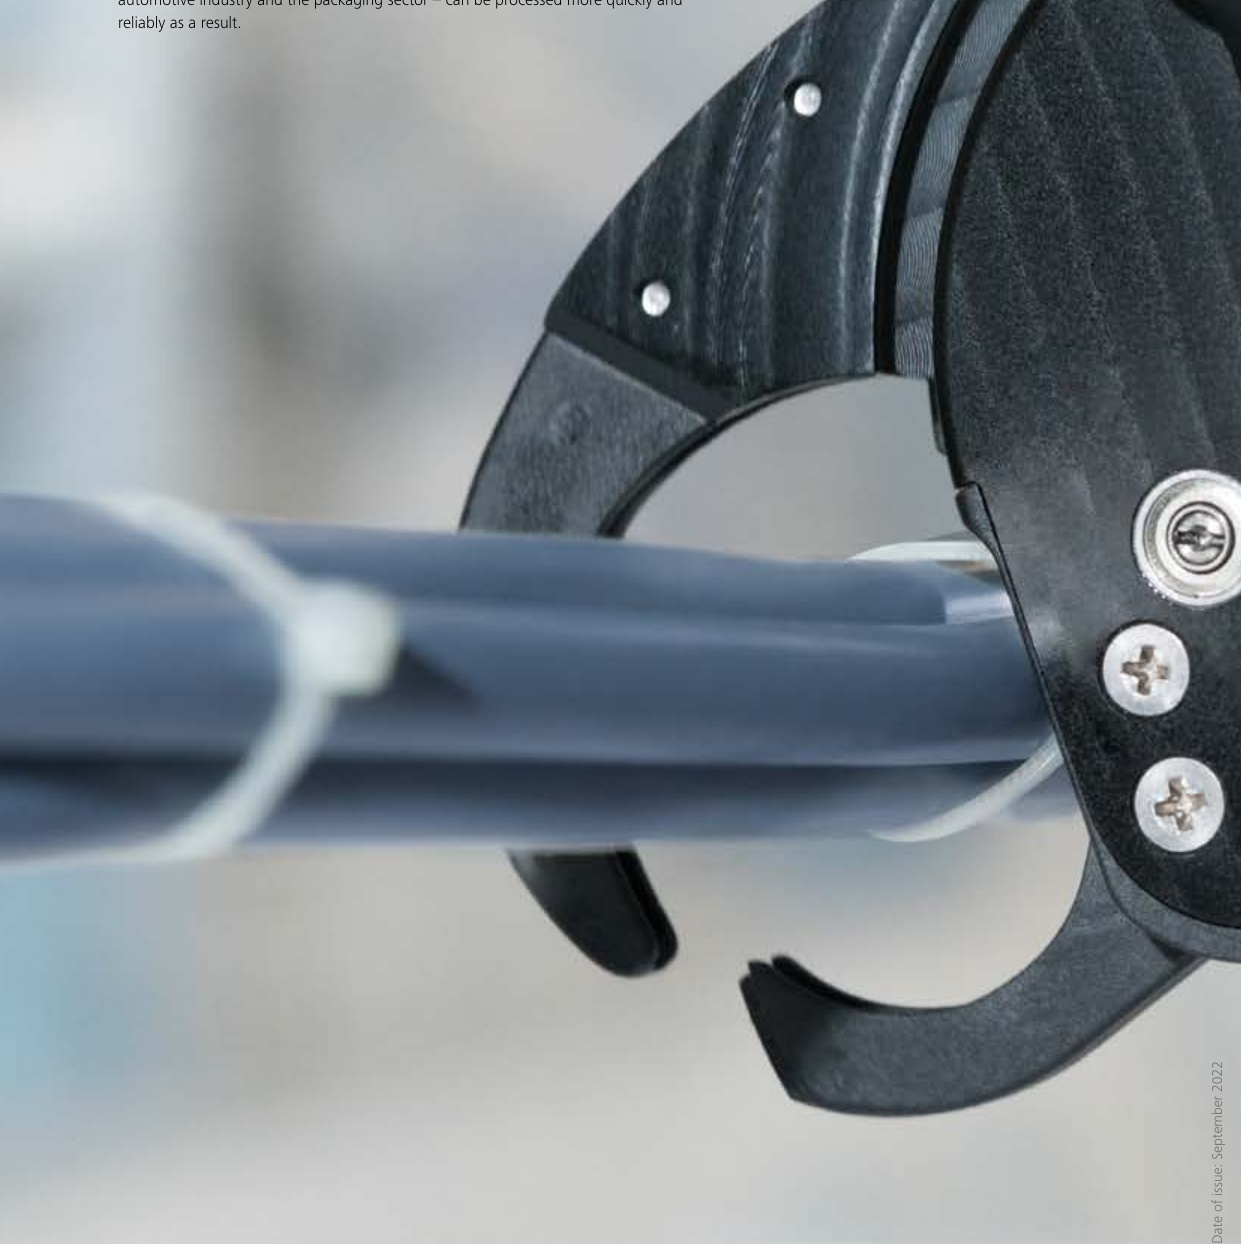

In [ ]:
from PIL import Image
extracted_imgs_path[0]

Image.open(extracted_imgs_path[0])

In [ ]:
import cloudinary
import cloudinary.uploader
import fitz 
from ultralytics import YOLO
import cv2
from pathlib import Path
import dotenv

dotenv.load_dotenv()

cloudinary.config(
    cloud_name=os.getenv("CLOUDINARY_CLOUD_NAME"),
    api_key=os.getenv("CLOUDINARY_API_KEY"),
    api_secret=os.getenv("CLOUDINARY_API_SECRET"),
)

def save_pictures_from_results(page_number, results, output_dir="output/pictures"):
    img = results.orig_img
    boxes = results.boxes
    names = results.names

    all_images = []

    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    pic_id = 0

    for box, cls in zip(boxes.xyxy.cpu().numpy(), boxes.cls.cpu().numpy()):
        class_name = names[int(cls)]

        if class_name == "Picture":
            x1, y1, x2, y2 = map(int, box)
            cropped_img = img[y1:y2, x1:x2]

            filename = output_path / f"page-{page_number + 1}_pic-{pic_id}.jpg"
            cv2.imwrite(str(filename), cropped_img)
            print(f"Saved: {filename}")
            pic_id += 1
            all_images.append(str(filename))
    if pic_id == 0:
        print(f"No pictures found on page {page_number}.")
    return all_images


def convert_pdf_to_images(pdf_path, output_folder="pdf_pages", dpi=300):
    os.makedirs(output_folder, exist_ok=True)
    doc = fitz.open(pdf_path)
    image_paths = []

    for page_num in range(len(doc)):
        page = doc.load_page(page_num)
        pix = page.get_pixmap(dpi=dpi)
        img_path = os.path.join(output_folder, f"page_{page_num + 1}.png")
        pix.save(img_path)
        image_paths.append(img_path)

    return image_paths

def upload_to_cloudinary(pdf_path):
    pdf_path = 'xyz.pdf'
    model_path = r"yolov8n-doclaynet.pt"

    images_folder = convert_pdf_to_images(pdf_path)

    extracted_imgs_path = []
    for page_number, image_path in enumerate(images_folder):
        img = cv2.imread(image_path, cv2.IMREAD_COLOR)
        model = YOLO(model_path)

        result = model.predict(img)[0]
        all_imgs = save_pictures_from_results(page_number, result, output_dir="output/pictures")
        extracted_imgs_path.extend(all_imgs)

    print(extracted_imgs_path)
    image_info = {}

    folder_name = 'new_pdf_parser'

    for single_image_path in extracted_imgs_path:
        public_id = single_image_path.split('\\')[-1].split('.')[0]
        upload_result = cloudinary.uploader.upload(single_image_path,
                                                public_id=public_id,asset_folder=folder_name)
        print(upload_result["secure_url"])
        image_info[single_image_path] = upload_result["secure_url"]
    return image_info



{'output\\pictures\\page-1_pic-0.jpg': 'https://res.cloudinary.com/dteprqxlx/image/upload/v1747837648/page-1_pic-0.jpg',
 'output\\pictures\\page-1_pic-1.jpg': 'https://res.cloudinary.com/dteprqxlx/image/upload/v1747837649/page-1_pic-1.jpg',
 'output\\pictures\\page-2_pic-0.jpg': 'https://res.cloudinary.com/dteprqxlx/image/upload/v1747837650/page-2_pic-0.jpg',
 'output\\pictures\\page-3_pic-0.jpg': 'https://res.cloudinary.com/dteprqxlx/image/upload/v1747837650/page-3_pic-0.jpg',
 'output\\pictures\\page-3_pic-1.jpg': 'https://res.cloudinary.com/dteprqxlx/image/upload/v1747837651/page-3_pic-1.jpg',
 'output\\pictures\\page-3_pic-2.jpg': 'https://res.cloudinary.com/dteprqxlx/image/upload/v1747837652/page-3_pic-2.jpg',
 'output\\pictures\\page-3_pic-3.jpg': 'https://res.cloudinary.com/dteprqxlx/image/upload/v1747837652/page-3_pic-3.jpg',
 'output\\pictures\\page-3_pic-4.jpg': 'https://res.cloudinary.com/dteprqxlx/image/upload/v1747837653/page-3_pic-4.jpg',
 'output\\pictures\\page-3_pic-5

In [ ]:
import base64
from ultralytics import YOLO
from pathlib import Path
import cv2
import fitz 
import os

def convert_pdf_to_images(pdf_path, output_folder="pdf_pages", dpi=300):
    os.makedirs(output_folder, exist_ok=True)
    doc = fitz.open(pdf_path)
    image_paths = []

    for page_num in range(len(doc)):
        page = doc.load_page(page_num)
        pix = page.get_pixmap(dpi=dpi)
        img_path = os.path.join(output_folder, f"page_{page_num + 1}.png")
        pix.save(img_path)
        image_paths.append(img_path)

    return image_paths



def save_pictures_from_results(page_number, results, output_dir="output/pictures"):
    img = results.orig_img
    boxes = results.boxes
    names = results.names

    all_images = []

    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    pic_id = 0

    for box, cls in zip(boxes.xyxy.cpu().numpy(), boxes.cls.cpu().numpy()):
        class_name = names[int(cls)]

        if class_name == "Table":
            x1, y1, x2, y2 = map(int, box)
            cropped_img = img[y1:y2, x1:x2]

            filename = output_path / f"page-{page_number + 1}_table-{pic_id}.jpg"
            cv2.imwrite(str(filename), cropped_img)
            print(f"Saved: {filename}")
            pic_id += 1
            all_images.append(str(filename))
    if pic_id == 0:
        print(f"No pictures found on page {page_number}.")
    return all_images


def extract_tables_info(pdf_path):
    model_path = r"yolov8n-doclaynet.pt"

    images_folder = convert_pdf_to_images(pdf_path)

    extracted_table = []
    for page_number, image_path in enumerate(images_folder):
        img = cv2.imread(image_path, cv2.IMREAD_COLOR)
        model = YOLO(model_path)

        result = model.predict(img)[0]
        all_tables = save_pictures_from_results(page_number, result, output_dir="output/tables")
        extracted_table.extend(all_tables)

    return extracted_table


def encode_image(image_path):
  with open(image_path, "rb") as image_file:
    return base64.b64encode(image_file.read()).decode('utf-8')

def openai_responses(open_ai_client,image_path):
    user_input = image_path.split('/')[-1].split('.')[0]
    base64_image = encode_image(image_path)
    response = open_ai_client.responses.create(
        model="gpt-4.1-nano-2025-04-14",
        input=[
            {
                "role": "system",
                "content": [
                    {
                        "type": "input_text",
                        "text": "You will receive an image and a page number along with an image number\n--------------------------------------------------------\nYou have to return a json which contains,\n\ntable > boolean\npage number > int\ntable number > int\nrows > list[tuple]\n--------------------------------------------------------\nAdditional Instructions: \n\n*** A table is a collection of rows and columns ***\n\n1) return each row as a tuple\n2) all tuples should contain same number of elements\n3) if there are empty values in the table then replace it with NaN\n4) if the given image does not contain a table return a json with the 'table' parameter as false and the others as empty \n5) treat headers as a row\n"                    }
                ]
            },
            {
                "role": "user",
                "content": [
                    {
                        "type": "input_image",
                        "image_url": f"data:image/png;base64,{base64_image}",
                    },
                    {
                        "type": "input_text",
                        "text": f"{user_input}",
                    }]
            }
        ],
    )

    return response

In [ ]:
from openai import OpenAI
import dotenv

dotenv.load_dotenv()
client = OpenAI()

pdf_path = "example_pdf_for_agent.pdf"
extract_tables = extract_tables_info(pdf_path)

response = openai_responses(client,extract_tables[0])
tables_json = []
for img_path in extract_tables[:20]:
    response = openai_responses(client,img_path)
    tables_json.append(response.output[0].content[0].text)

In [18]:
def save_dict_to_json(data, filename="image_links.json"):
    with open(filename, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=4)
    
    return filename

In [20]:
import json
save_dict_to_json(tables_json, filename="tables_json.json")

'tables_json.json'

In [12]:
import aspose.words as aw

doc = aw.Document("test_doc.docx")

save_options = aw.saving.ImageSaveOptions(aw.SaveFormat.JPEG)
save_options.vertical_resolution = 300
save_options.horizontal_resolution = 300

for page in range(doc.page_count):
    save_options.page_set = aw.saving.PageSet(page)
    doc.save(fr"pdf_pages\Output1_{page + 1}.jpg", save_options)

In [22]:
input_path = "test_doc.docx"
ext = os.path.splitext(input_path)[1].lower()

In [13]:
def convert_pdf_to_images(file_path, output_folder="pdf_pages", dpi=300):
    os.makedirs(output_folder, exist_ok=True)
    image_paths = []

    file_ext = os.path.splitext(file_path)[1].lower()

    if file_ext == ".pdf":
        doc = fitz.open(file_path)
        for page_num in range(len(doc)):
            page = doc.load_page(page_num)
            pix = page.get_pixmap(dpi=dpi)
            img_path = os.path.join(output_folder, f"page_{page_num + 1}.png")
            pix.save(img_path)
            image_paths.append(img_path)

    elif file_ext in [".doc", ".docx"]:
        doc = aw.Document(file_path)
        save_options = aw.saving.ImageSaveOptions(aw.SaveFormat.JPEG)
        save_options.vertical_resolution = dpi
        save_options.horizontal_resolution = dpi

        for page in range(doc.page_count):
            save_options.page_set = aw.saving.PageSet(page)
            img_path = os.path.join(output_folder, f"page_{page + 1}.jpg")
            doc.save(img_path, save_options)
            image_paths.append(img_path)

    else:
        raise ValueError("Unsupported file type. Only .pdf, .doc, and .docx are supported.")

    return image_paths

In [ ]:
import os
import fitz
# input_path = "test_doc.docx"
input_path = 'xyz.pdf'

image_paths = convert_pdf_to_images(input_path)

In [ ]:
import os
import pdfplumber
import aspose.words as aw
from typing import Dict

def extract_text_from_file(filepath) -> str:
    assert context.context.pdf_path, "PDF path not set. Please provide a valid file first."
    file_path = context.context.pdf_path
    extracted_text: Dict[int, str] = {}

    ext = os.path.splitext(file_path)[1].lower()

    if ext == ".pdf":
        with pdfplumber.open(file_path) as pdf:
            for page_no, page in enumerate(pdf.pages):
                text = page.extract_text()
                if text:
                    extracted_text[page_no + 1] = text

    elif ext in [".docx", ".doc"]:
        doc = aw.Document(file_path)
        # for i in range(doc.page_count):
            # extractor = aw.layout.LayoutCollector(doc)
            # start = extractor.get_start_page_index(doc.get_child_nodes(aw.NodeType.PARAGRAPH, True)[0])
        text = doc.get_text()
            # Get text from the page using text extraction with page range
            # text = doc.extract_text(aw.saving.sPageSet(i))
        extracted_text = text.strip()
    else:
        raise ValueError("Unsupported file type for text extraction.")

    text_path = save_dict_to_json(extracted_text, filename="extracted_text.json")
    return f"Text saved at: {text_path}"


In [43]:
input_path = "test_doc.docx"
# input_path = 'xyz.pdf'
import json

def save_dict_to_json(data, filename="image_links.json"):
    with open(filename, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=4)
    
    return filename
extract_text_from_file(input_path)

'Text saved at: extracted_text.json'

In [ ]:
import json

def load_json(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return data

# Example usage
data = load_json("extracted_text.json")
print(data)


Evaluation Only. Created with Aspose.Words. Copyright 2003-2025 Aspose Pty Ltd.ation-rag-techniques-you-should-know-b45de9071c79" https://homayounsrp.medium.com/6-types-of-retrieval-augmented-generation-rag-techniques-you-should-know-b45de9071c79-with-langchain-and-openai-83bcdd073dfb


In [55]:
data.split('\r')

['Created with an evaluation copy of Aspose.Words. To remove all limitations, you can use Free Temporary License \x13 HYPERLINK "https://products.aspose.com/words/temporary-license/" \x14https://products.aspose.com/words/temporary-license/\x15',
 'Basic Echo Bot: ',
 '\x13 HYPERLINK "https://docs.streamlit.io/develop/tutorials/chat-and-llm-apps/build-conversational-apps" \x14https://docs.streamlit.io/develop/tutorials/chat-and-llm-apps/build-conversational-apps\x15',
 '',
 '',
 'Basic Chat Bot with OpenAI: ',
 '\x13 HYPERLINK "https://docs.streamlit.io/develop/tutorials/chat-and-llm-apps/build-conversational-apps" \\l "build-a-chatgpt-like-app" \x14https://docs.streamlit.io/develop/tutorials/chat-and-llm-apps/build-conversational-apps#build-a-chatgpt-like-app\x15',
 'Chatbot using OpenAI and Langchain: ',
 '\x13 HYPERLINK "https://docs.streamlit.io/develop/tutorials/chat-and-llm-apps/llm-quickstart" \x14https://docs.streamlit.io/develop/tutorials/chat-and-llm-apps/llm-quickstart\x15',


In [78]:
import json

# Load from a file
with open("image_links.json", "r") as file:
    data = json.load(file)

type(data)

dict

In [85]:
data[list(data.keys())[0]][0]

'https://res.cloudinary.com/dteprqxlx/image/upload/v1748205929/page-1_pic-0.jpg'